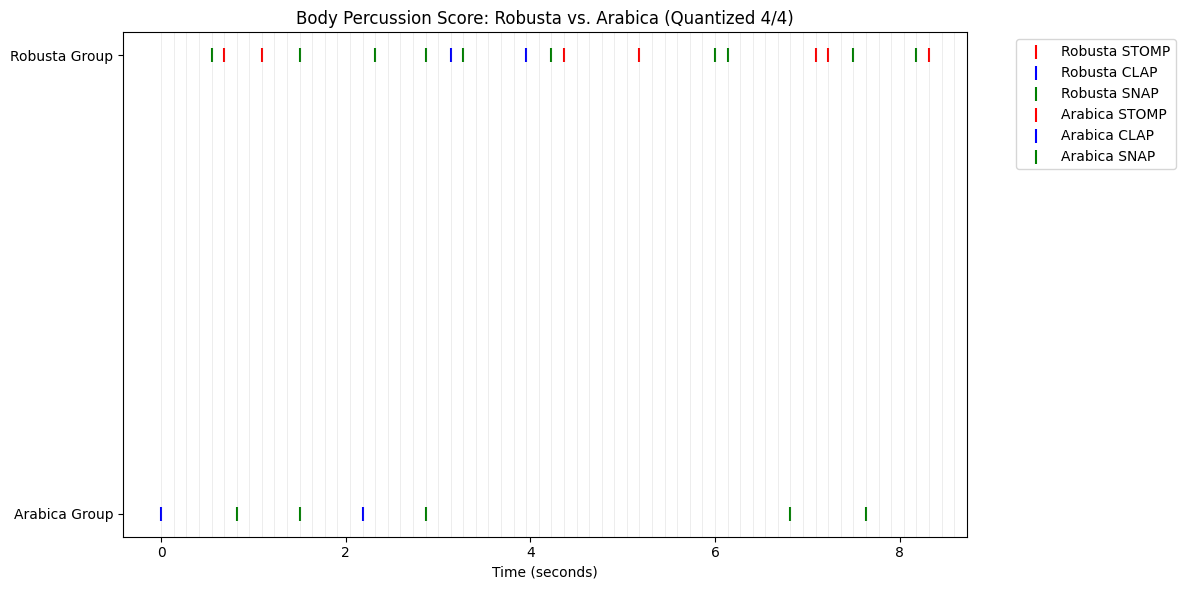

In [3]:
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

# --- 1. Configuration ---
bpm = 110
sr = 44100  # Sample rate
measures = 4
beats_per_measure = 4
subdivisions = 4  # 16th notes
total_steps = measures * beats_per_measure * subdivisions

# Calculate timings
seconds_per_beat = 60 / bpm
step_duration = seconds_per_beat / subdivisions
total_duration = total_steps * step_duration

# --- 2. Simulated LCMS Data & Quantization ---
def get_quantized_grid(seed, density):
    np.random.seed(seed)
    # Simulate peaks (0 to 1 range)
    times = {"STOMP": [], "CLAP": [], "SNAP": []}
    
    for step in range(total_steps):
            if np.random.rand() < (0.3 * density): # Probability of a hit
                intensity = np.random.rand() * 1.5
                time_in_seconds = step * step_duration
                
                if intensity > 1.2: times["STOMP"].append(time_in_seconds)
                elif intensity > 0.8: times["CLAP"].append(time_in_seconds)
                else: times["SNAP"].append(time_in_seconds)
    return times

score_robusta = get_quantized_grid(42, 0.7)
score_arabica = get_quantized_grid(7, 0.5)

# --- 3. Synthesizing with Librosa ---
def synthesize_percussion(grid):
    track = np.zeros(int(sr * total_duration))        
    # Mapping Move -> (Frequency, Volume)
    settings = {
        "STOMP": (100, 1.0), 
        "CLAP": (400, 0.7), 
        "SNAP": (800, 0.5)
    }

    for move, (freq, vol) in settings.items():
            if grid[move]: # Only if there are hits
                clicks = librosa.clicks(times=grid[move], sr=sr, 
                                        click_freq=freq, click_duration=0.1, 
                                        length=len(track))
                track += clicks * vol
                
    return track

# Generate Audio Tracks
audio_r = synthesize_percussion(score_robusta)
audio_a = synthesize_percussion(score_arabica)

# --- 4. Add Metronome (Downbeats) ---
metronome_times = np.arange(0, total_duration, seconds_per_beat)
metronome_clicks = librosa.clicks(times=metronome_times, sr=sr, 
                                  click_freq=2000, click_duration=0.05, length=len(audio_r))

# --- 5. Mix and Export ---
# Robusta (Left), Arabica (Right), Metronome (Center)
stereo_mix = np.zeros((2, len(audio_r)))
stereo_mix[0] = audio_r + (metronome_clicks * 0.3)  # Left
stereo_mix[1] = audio_a + (metronome_clicks * 0.3)  # Right
stereo_mix = librosa.util.normalize(stereo_mix)

# Save to file
sf.write('coffee_percussion_guide.wav', stereo_mix.T, sr)

# --- 6. Plot ---
plt.figure(figsize=(12, 6))

def plot_group(times_dict, offset, label, color_map):
    for move, color in color_map.items():
        plt.scatter(times_dict[move], [offset] * len(times_dict[move]), 
                    label=f"{label} {move}", s=100, color=color, marker='|')

colors = {"STOMP": "red", "CLAP": "blue", "SNAP": "green"}
plot_group(score_robusta, 2, "Robusta", colors)
plot_group(score_arabica, 1, "Arabica", colors)

# Add grid lines for 16th notes
for i in range(total_steps + 1):
    plt.axvline(i * step_duration, color='gray', alpha=0.2, lw=0.5)

plt.yticks([1, 2], ["Arabica Group", "Robusta Group"])
plt.xlabel("Time (seconds)")
plt.title("Body Percussion Score: Robusta vs. Arabica (Quantized 4/4)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()